# **Customer Personality & Purchasing Behavior Analysis**

**Dataset Overview**

Perusahaan menghadapi tantangan dalam memahami karakter dan perilaku pelanggan secara menyeluruh. Tanpa pemahaman ini, strategi pemasaran sering kali tidak tepat sasaran, sehingga kurang efektif dalam meningkatkan penjualan dan loyalitas pelanggan.

Melalui analisis data pelanggan, proyek ini bertujuan untuk membantu perusahaan mengenali pola perilaku konsumen dan menyusun strategi pemasaran yang lebih tepat, efisien, dan berbasis data.

**Tujuan**

1. Siapa pelanggan yang paling menguntungkan?

Mengetahui kelompok pelanggan yang memberikan kontribusi terbesar terhadap pendapatan, sehingga perusahaan dapat lebih fokus dalam mempertahankan mereka.

2. Apakah kampanye pemasaran sudah efektif?

Menganalisis apakah strategi marketing yang dilakukan benar-benar menarik perhatian pelanggan atau masih perlu diperbaiki.

3. Faktor apa yang memengaruhi pelanggan untuk membeli?

Memahami hal-hal yang mendorong pelanggan melakukan pembelian, seperti pendapatan, usia, atau kebiasaan belanja.

4. Apakah pelanggan dengan pendapatan tinggi selalu lebih sering membeli?

Menguji apakah asumsi umum ini benar, atau justru ada pola lain yang lebih penting.

5. Pelanggan lebih suka belanja lewat channel apa?

Mengetahui apakah pelanggan lebih aktif berbelanja melalui website, katalog, atau langsung ke toko.

6. Pelanggan mana yang mulai tidak aktif?

Mengidentifikasi pelanggan yang berpotensi berhenti membeli agar perusahaan bisa mengambil tindakan lebih awal.

In [14]:
# ==============================
# IMPORT LIBRARY
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

sns.set_style("whitegrid")

In [29]:
# ==============================
# LOAD DATASET
# ==============================

df = pd.read_csv('/content/marketing_campaign.csv', sep='\t')
print("Data awal:", df.shape)
df.head()

Data awal: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [30]:
# ===============
# DATA OVERVIEW
# ===============

# 1. Ukuran dataset
print("=== Dataset ===")
print(f"Jumlah baris : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")

# 2. Tipe data & non-null count
print("\n=== Info Dataset ===")
df.info()

# 3. Statistik deskriptif
print("\n=== Statistik Deskriptif ===")
df.describe().T

=== Dataset ===
Jumlah baris : 2240
Jumlah kolom : 29

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [31]:
# ====================
# PERBAIKAN TIPE DATA
# ====================

# 1. Konversi Dt_Customer ke datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

# Tambah fitur turunan dari tanggal — sekalian dibuat sekarang
df['Customer_Since_Days'] = (pd.Timestamp('2025-01-01') - df['Dt_Customer']).dt.days

print("Tipe Dt_Customer sekarang:", df['Dt_Customer'].dtype)
print("Contoh Customer_Since_Days:")
print(df[['Dt_Customer', 'Customer_Since_Days']].head())

# 2. Drop kolom konstan (tidak informatif)
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])
print("\nKolom Z_CostContact & Z_Revenue berhasil di-drop")

# 3. Set ID sebagai index (bukan kolom biasa)
df = df.set_index('ID')
print("ID dijadikan index")

# Konfirmasi shape & tipe data sekarang
print(f"\nShape sekarang: {df.shape}")
print("\nTipe data setelah perbaikan:")
print(df.dtypes)

Tipe Dt_Customer sekarang: datetime64[ns]
Contoh Customer_Since_Days:
  Dt_Customer  Customer_Since_Days
0  2012-09-04                 4502
1  2014-03-08                 3952
2  2013-08-21                 4151
3  2014-02-10                 3978
4  2014-01-19                 4000

Kolom Z_CostContact & Z_Revenue berhasil di-drop
ID dijadikan index

Shape sekarang: (2240, 27)

Tipe data setelah perbaikan:
Year_Birth                      int64
Education                      object
Marital_Status                 object
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases        

# DATA CLEANING

=== Missing Value Report ===
        Missing Count  Missing (%)
Income             24         1.07


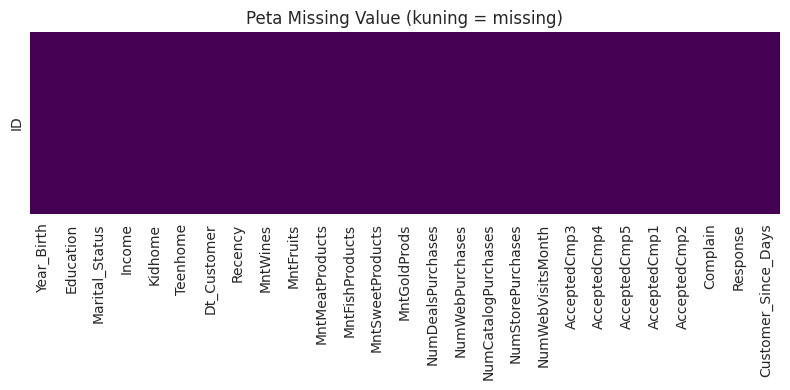

In [32]:
# ==============================
# CEK MISSING VALUE
# ==============================

# 1. Hitung missing value
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)': missing_pct.round(2)
}).sort_values('Missing Count', ascending=False)

# Tampilkan hanya yang ada missing value nya
print("=== Missing Value Report ===")
missing_report = missing_df[missing_df['Missing Count'] > 0]

if len(missing_report) == 0:
    print("Tidak ada missing value!")
else:
    print(missing_report)

# 2. Visualisasi
plt.figure(figsize=(8, 4))
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis',
    yticklabels=False
)
plt.title('Peta Missing Value (kuning = missing)')
plt.tight_layout()
plt.show()

Jumlah missing Income : 24
Persentase            : 1.07%

Mean Income   : 52,247
Median Income : 51,382


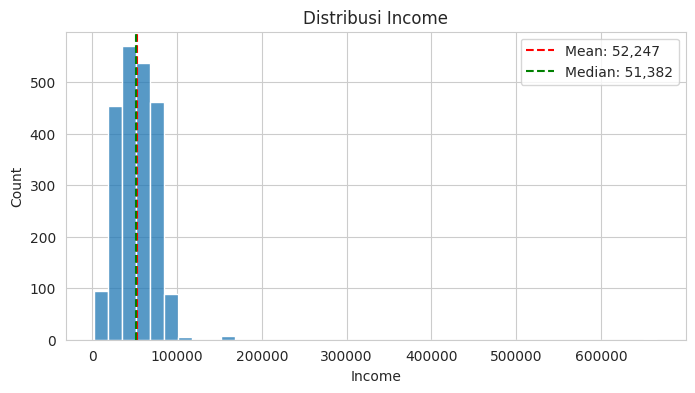


Opsi A dipilih: hapus 24 baris missing Income
Shape sekarang: (2216, 27)


In [33]:
# ==============================
# HANDLE MISSING VALUE - INCOME
# ==============================

print(f"Jumlah missing Income : {df['Income'].isnull().sum()}")
print(f"Persentase            : {df['Income'].isnull().mean()*100:.2f}%")
print(f"\nMean Income   : {df['Income'].mean():,.0f}")
print(f"Median Income : {df['Income'].median():,.0f}")

# Visualisasi distribusi Income dulu sebelum memutuskan
plt.figure(figsize=(8, 4))
sns.histplot(df['Income'].dropna(), bins=40)
plt.axvline(df['Income'].mean(), color='red', linestyle='--', label=f"Mean: {df['Income'].mean():,.0f}")
plt.axvline(df['Income'].median(), color='green', linestyle='--', label=f"Median: {df['Income'].median():,.0f}")
plt.title('Distribusi Income')
plt.legend()
plt.show()

# OPSI A: Hapus baris missing (karena hanya 1%, aman)
df = df.dropna(subset=['Income'])
print(f"\nOpsi A dipilih: hapus 24 baris missing Income")
print(f"Shape sekarang: {df.shape}")

# OPSI B: Isi dengan median (pakai ini kalau datanya lebih besar & sayang dibuang)
# df['Income'] = df['Income'].fillna(df['Income'].median())
# print(f"\nOpsi B dipilih: isi missing Income dengan median {df['Income'].median():,.0f}")

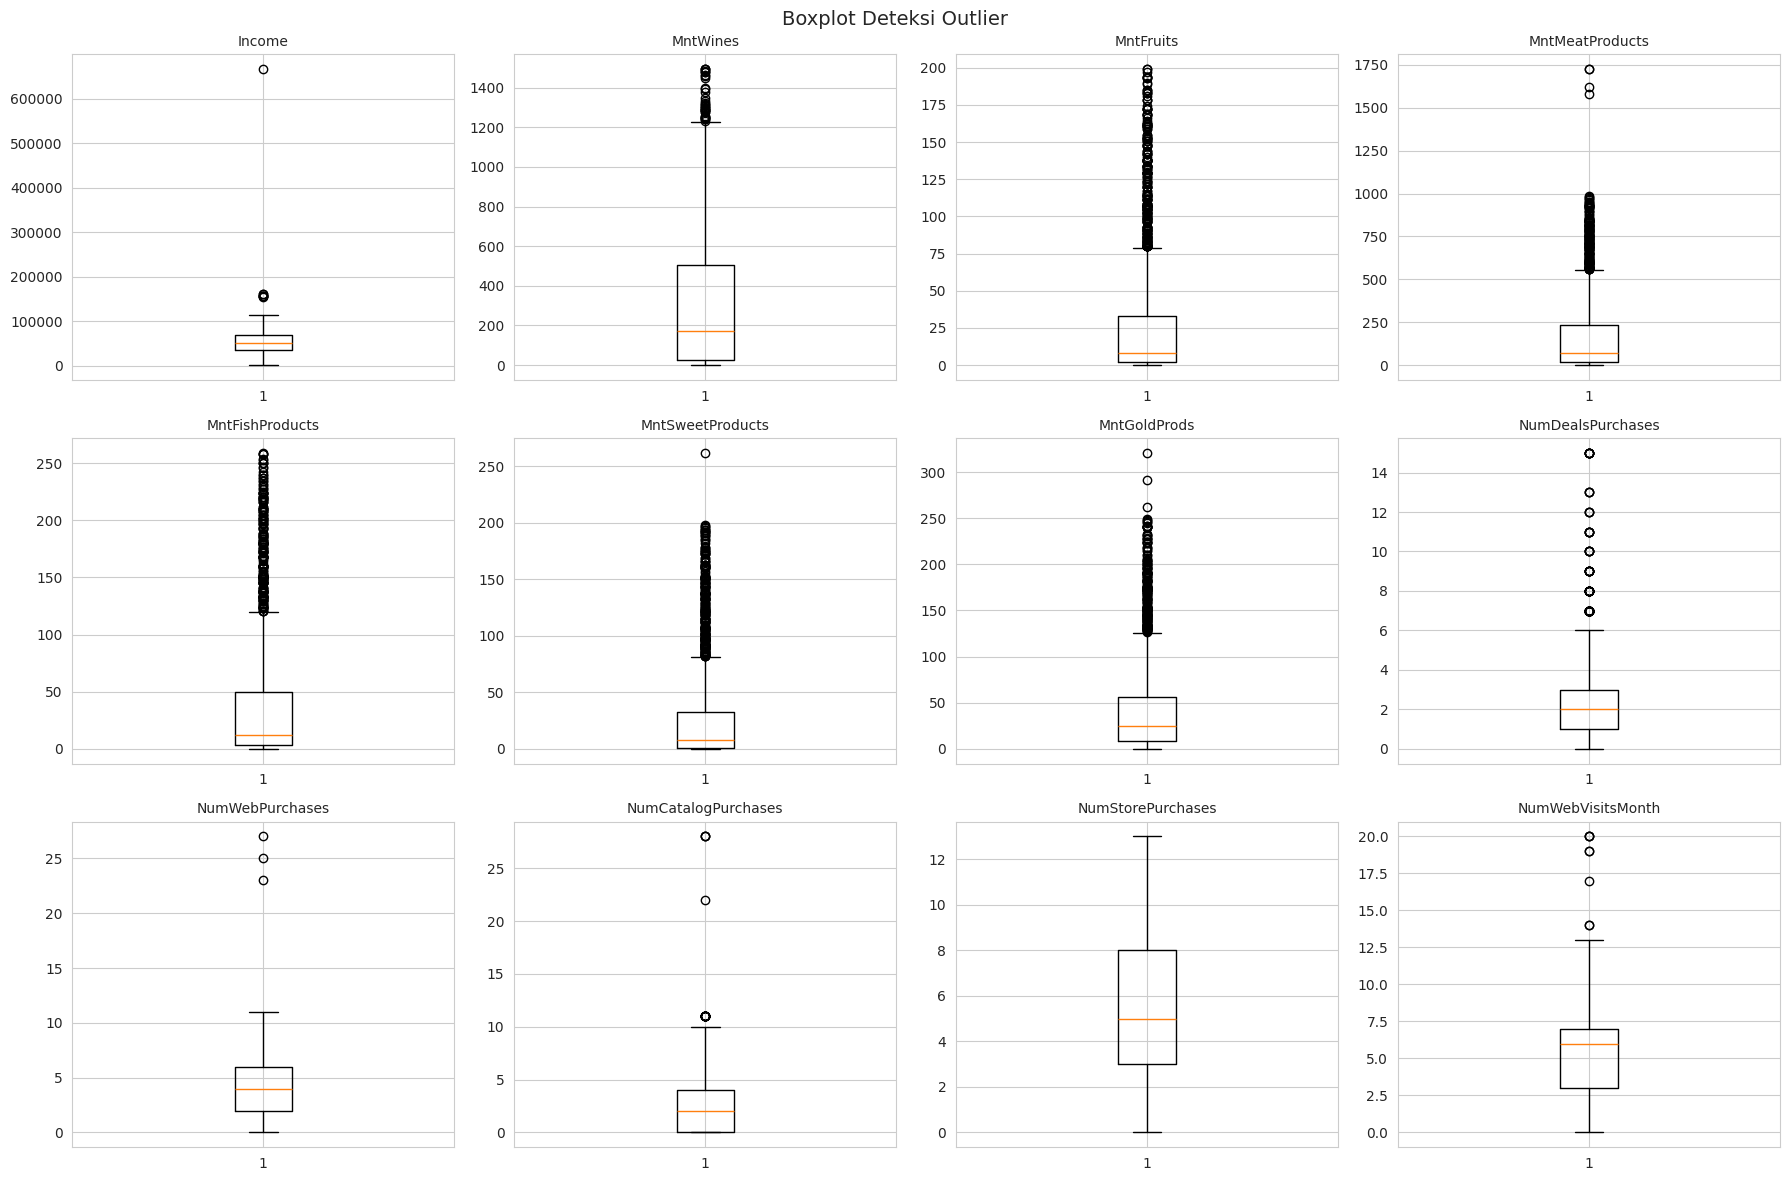

In [36]:
# ==============================
# CEK OUTLIER - VISUALISASI
# ==============================

num_cols = [
    'Income', 'MntWines', 'MntFruits',
    'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth'
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=10)

plt.suptitle('Boxplot Deteksi Outlier', fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
# ==============================
# CEK OUTLIER - HITUNG ANGKANYA
# ==============================

print("=== Deteksi Outlier dengan Metode IQR ===\n")

outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_rows = df[(df[col] < lower) | (df[col] > upper)]
    outlier_count = len(outlier_rows)
    outlier_pct = (outlier_count / len(df)) * 100

    outlier_summary.append({
        'Kolom'          : col,
        'Batas Bawah'    : round(lower, 1),
        'Batas Atas'     : round(upper, 1),
        'Jumlah Outlier' : outlier_count,
        'Persentase (%)'  : round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(
    'Jumlah Outlier', ascending=False
)
print(outlier_df.to_string(index=False))

=== Deteksi Outlier dengan Metode IQR ===

              Kolom  Batas Bawah  Batas Atas  Jumlah Outlier  Persentase (%)
          MntFruits        -44.5        79.5             246           11.10
   MntSweetProducts        -47.0        81.0             246           11.10
    MntFishProducts        -67.5       120.5             222           10.02
       MntGoldProds        -61.5       126.5             205            9.25
    MntMeatProducts       -308.4       556.6             174            7.85
  NumDealsPurchases         -2.0         6.0              84            3.79
           MntWines       -697.5      1226.5              35            1.58
NumCatalogPurchases         -6.0        10.0              23            1.04
             Income     -14525.5    118350.5               8            0.36
  NumWebVisitsMonth         -3.0        13.0               8            0.36
    NumWebPurchases         -4.0        12.0               3            0.14
  NumStorePurchases         -4.5 

Ukuran data sebelum : (2208, 27)
Income max    : 113,734

Batas atas Income (IQR) : 117,930
Baris yang dihapus      : 0

Ukuran data sesudah : (2208, 27)
Income max    : 113,734


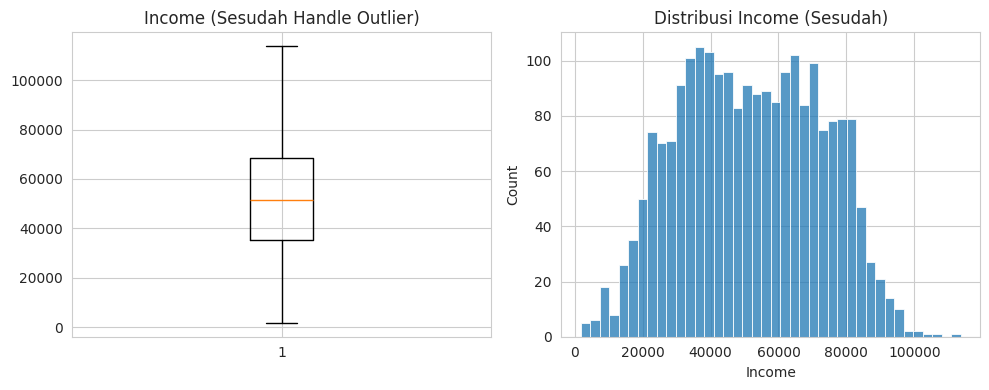

In [40]:
# ==============================
# HANDLE OUTLIER INCOME
# ==============================

print(f"Ukuran data sebelum : {df.shape}")
print(f"Income max    : {df['Income'].max():,.0f}")

# Tentukan batas atas dengan IQR
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

print(f"\nBatas atas Income (IQR) : {upper:,.0f}")
print(f"Baris yang dihapus      : {len(df[df['Income'] > upper])}")

# Hapus outlier Income
df = df[df['Income'] <= upper]

print(f"\nUkuran data sesudah : {df.shape}")
print(f"Income max    : {df['Income'].max():,.0f}")

# Visualisasi sebelum vs sesudah
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(df['Income'])
axes[0].set_title('Income (Sesudah Handle Outlier)')

sns.histplot(df['Income'], bins=40, ax=axes[1])
axes[1].set_title('Distribusi Income (Sesudah)')

plt.tight_layout()
plt.show()

**Hasil Data Cleaning**

Proses data cleaning dimulai dari pengecekan missing value hingga penanganan outlier. Berikut ringkasan seluruh proses yang dilakukan.

**Missing Value**
Dari hasil pengecekan, hanya kolom Income yang memiliki missing value sebanyak 24 baris (1.07%) dari total 2.240 data. Karena jumlahnya sangat kecil, keputusan yang diambil adalah menghapus baris tersebut sehingga data berkurang menjadi 2.216 baris.

**Deteksi Outlier**
Setelah missing value ditangani, dilakukan deteksi outlier menggunakan metode IQR pada seluruh kolom numerik. Dari hasil deteksi, ditemukan bahwa kolom pengeluaran produk seperti MntFruits, MntSweetProducts, MntFishProducts, MntGoldProds, MntMeatProducts, dan MntWines memiliki cukup banyak outlier berkisar 1–11%. Namun outlier pada kolom-kolom tersebut diputuskan untuk dibiarkan karena mencerminkan perilaku belanja nyata pelanggan, bukan kesalahan data.

**Penanganan Outlier Income**
Satu-satunya kolom yang outliernya ditangani adalah Income. Berdasarkan metode IQR, batas atas yang diperoleh adalah 118.350. Ditemukan 8 baris dengan nilai Income di atas batas tersebut, termasuk 1 nilai ekstrem sebesar 666.666 yang hampir pasti merupakan kesalahan input data. Kedelapan baris tersebut dihapus sehingga data akhir menjadi **2.208 baris** dengan nilai Income maksimum 113.734.

Setelah penanganan outlier, distribusi Income terlihat jauh lebih normal dan simetris dibandingkan sebelumnya, dengan sebagian besar pelanggan memiliki Income di rentang 30.000–90.000. Boxplot juga sudah tidak menunjukkan titik ekstrem yang mencolok, yang mengonfirmasi bahwa data Income sudah bersih dan siap digunakan untuk analisis selanjutnya.

In [41]:
# ==============================
# CEK ANOMALI KATEGORIKAL
# ==============================

cat_cols = ['Education', 'Marital_Status']

for col in cat_cols:
    print(f"=== {col} ===")
    print(df[col].value_counts())
    print()

=== Education ===
Education
Graduation    1113
PhD            477
Master         364
2n Cycle       200
Basic           54
Name: count, dtype: int64

=== Marital_Status ===
Marital_Status
Married     854
Together    569
Single      471
Divorced    231
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64



In [42]:
# ==============================
# CLEANING KATEGORIKAL
# ==============================

# 1. Education — ganti 2n Cycle jadi Master
df['Education'] = df['Education'].replace({'2n Cycle': 'Master'})

# 2. Marital_Status — hanya gabungkan Alone ke Single
df['Marital_Status'] = df['Marital_Status'].replace({'Alone': 'Single'})

# 3. Marital_Status — hapus nilai tidak valid
df = df[~df['Marital_Status'].isin(['Absurd', 'YOLO'])]

# Konfirmasi sesudah
print("=== Education (Sesudah) ===")
print(df['Education'].value_counts())

print("\n=== Marital_Status (Sesudah) ===")
print(df['Marital_Status'].value_counts())

print(f"\nShape sekarang: {df.shape}")

=== Education (Sesudah) ===
Education
Graduation    1112
Master         563
PhD            475
Basic           54
Name: count, dtype: int64

=== Marital_Status (Sesudah) ===
Marital_Status
Married     854
Together    569
Single      474
Divorced    231
Widow        76
Name: count, dtype: int64

Shape sekarang: (2204, 27)


**Anomali Kategorikal**
Pengecekan kolom kategorikal dilakukan pada kolom Education dan Marital_Status.
Pada kolom Education, ditemukan nilai "2n Cycle" yang merupakan penamaan tidak
standar untuk jenjang pendidikan Master/S2, sehingga diganti menjadi "Master"
agar lebih konsisten dan mudah dipahami.

Pada kolom Marital_Status, ditemukan beberapa anomali. Nilai "Alone" digabungkan ke dalam kategori "Single" karena keduanya memiliki makna yang sama. Sementara nilai "Absurd" dan "YOLO" dihapus karena bukan kategori yang valid (total 4 baris).
Nilai "Together" diputuskan untuk tetap dipertahankan sebagai kategori tersendiri karena maknanya berbeda dengan "Married" Together merujuk pada pasangan yang tinggal bersama namun belum menikah secara resmi.

Setelah seluruh proses data cleaning selesai, data yang semula berjumlah 2.240 baris berkurang menjadi **2.204 baris** dengan rincian 24 baris dihapus karena missing value Income, 8 baris karena outlier Income, dan 4 baris karena nilai Marital_Status yang tidak valid.

In [44]:
# ==============================
# FEATURE ENGINEERING
# ==============================

# 1. Usia pelanggan
df['Age'] = 2025 - df['Year_Birth']

# 2. Total pengeluaran semua kategori produk
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

# 3. Total transaksi semua channel
df['Total_Purchase'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

# 4. Total campaign yang diterima
df['Total_AcceptedCmp'] = (
    df['AcceptedCmp1'] +
    df['AcceptedCmp2'] +
    df['AcceptedCmp3'] +
    df['AcceptedCmp4'] +
    df['AcceptedCmp5']
)

# 5. Lama jadi pelanggan (dalam hari)
reference_date = df['Dt_Customer'].max()
print(f"Tanggal referensi: {reference_date}")

df['Customer_Since_Days'] = (
    reference_date - df['Dt_Customer']
).dt.days

# 6. Kelompok usia
df['Age_Group'] = pd.cut(
    df['Age'],
    bins  = [0, 30, 45, 60, 90],
    labels= ['<30', '30-45', '45-60', '60+']
)

# Konfirmasi
print("Feature baru berhasil dibuat!")
print(f"\nShape sekarang: {df.shape}")
print("\nPreview kolom baru:")
df[['Age', 'Age_Group', 'Total_Spending',
    'Total_Purchase', 'Total_AcceptedCmp',
    'Customer_Since_Days']].head()

Tanggal referensi: 2014-06-29 00:00:00
Feature baru berhasil dibuat!

Shape sekarang: (2204, 32)

Preview kolom baru:


,Age,Age_Group,Total_Spending,Total_Purchase,Total_AcceptedCmp,Customer_Since_Days
ID,,,,,,
5524,68,60+,1617,22,0,663
2174,71,60+,27,4,0,113
4141,60,45-60,776,20,0,312
6182,41,30-45,53,6,0,139
5324,44,30-45,422,14,0,161


**Feature Engineering**

Setelah data bersih, dibuat beberapa fitur baru yang lebih bermakna untuk analisis. Age dihitung dari tahun lahir pelanggan untuk mengetahui distribusi usia. Total_Spending dibuat dengan menjumlahkan seluruh pengeluaran produk (wines, fruits, meat, fish, sweet, gold) sebagai representasi nilai belanja keseluruhan tiap pelanggan. Total_Purchase menjumlahkan transaksi dari semua channel (web, catalog, store) untuk melihat seberapa aktif pelanggan berbelanja. Total_AcceptedCmp mencatat berapa banyak campaign yang diterima tiap pelanggan sebagai indikator responsivitas terhadap marketing. Customer_Since_Days menghitung sudah berapa lama bergabung dihitung dari tanggal registrasi hingga tanggal pelanggan terakhir masuk di dataset. Terakhir, Age_Group mengelompokkan usia ke dalam 4 kategori (<30, 30-45, 45-60, 60+) untuk memudahkan analisis demografis.

# EDA (Exploratory Data Analysis)

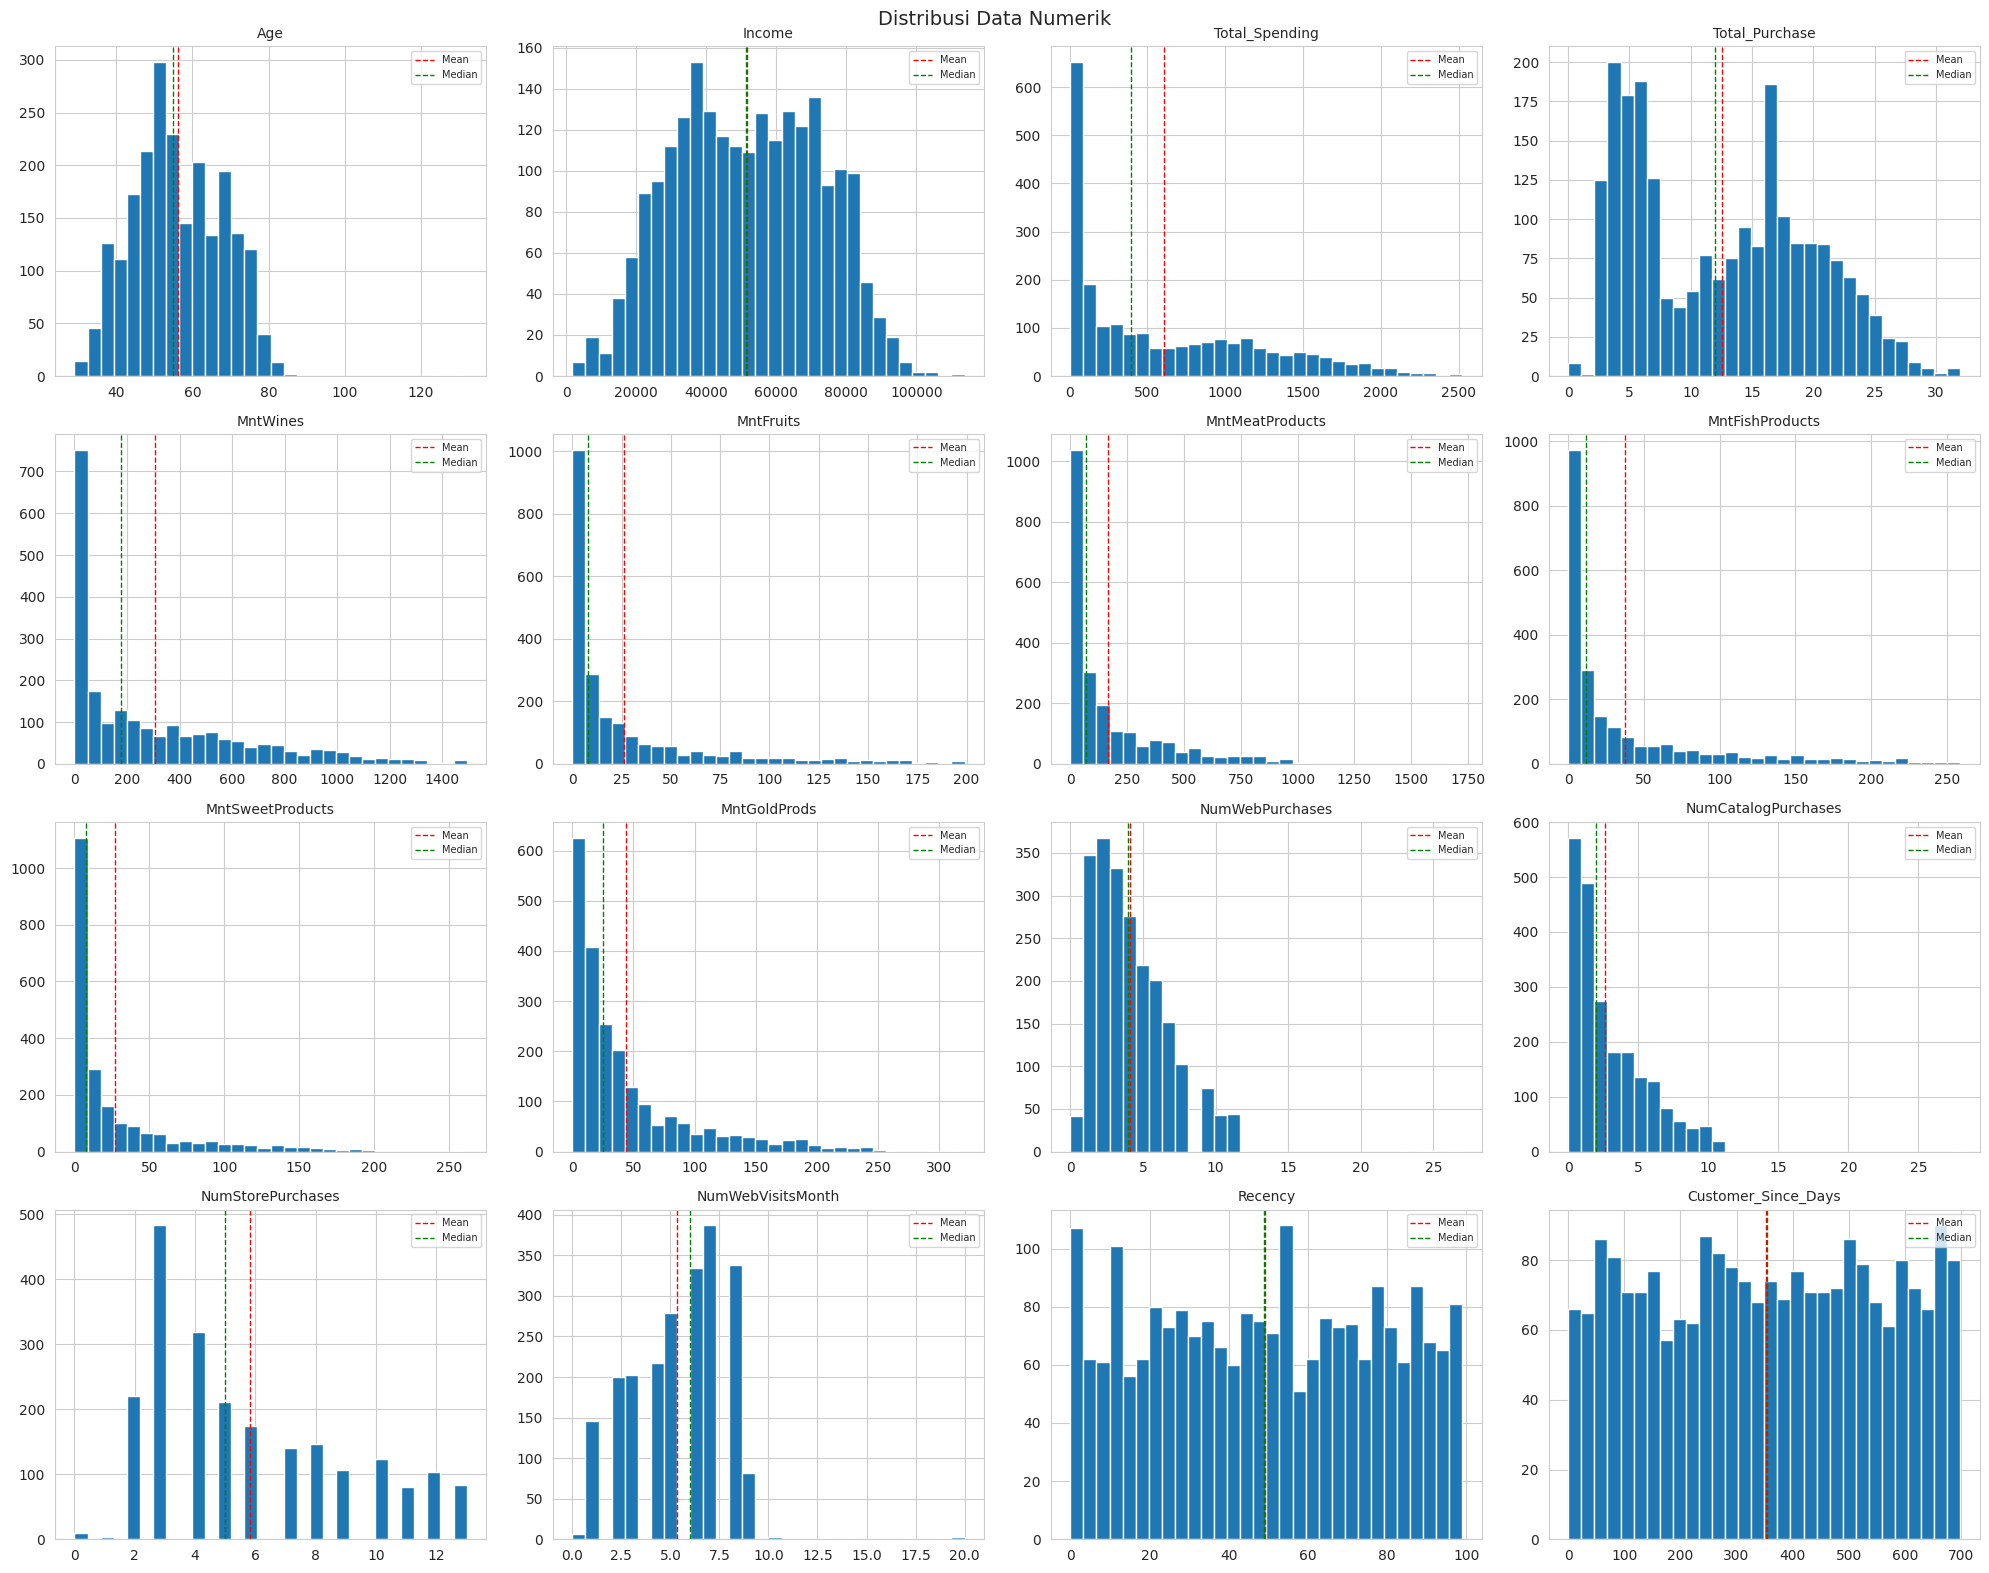

In [45]:
# =======================
# DISTRIBUSI DATA NUMERIK
# =======================

num_cols = [
    'Age', 'Income', 'Total_Spending', 'Total_Purchase',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth',
    'Recency', 'Customer_Since_Days'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='white')
    axes[i].axvline(df[col].mean(), color='red',
                    linestyle='--', linewidth=1, label='Mean')
    axes[i].axvline(df[col].median(), color='green',
                    linestyle='--', linewidth=1, label='Median')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

plt.suptitle('Distribusi Data Numerik', fontsize=14)
plt.tight_layout()
plt.show()

**Distribusi Data Numerik**

Dari visualisasi distribusi data numerik, diperoleh beberapa temuan penting.  Mayoritas pelanggan berusia 40–60 tahun dengan distribusi yang sedikit right-skewed, sementara pelanggan berusia di bawah 30 tahun sangat sedikit Distribusi Income sudah relatif normal setelah outlier dihapus, dengan
mayoritas pelanggan berpenghasilan 40.000–80.000.

Total_Spending menunjukkan distribusi yang sangat right-skewed — sebagian
besar pelanggan memiliki total belanja rendah (di bawah 500), namun ada
segmen kecil yang belanja hingga 2.500. Pola serupa terlihat pada semua
kolom pengeluaran produk (MntWines, MntFruits, MntMeatProducts, dll) yang
mengonfirmasi bahwa hanya segmen tertentu yang aktif membeli tiap kategori
produk.

Total_Purchase menunjukkan distribusi bimodal dengan dua puncak di sekitar
3–5 dan 13–15 transaksi, mengindikasikan adanya dua kelompok pelanggan
dengan perilaku pembelian yang berbeda. NumStorePurchases memiliki distribusi
paling merata dibanding channel lain, konsisten dengan temuan bahwa store
adalah channel belanja favorit pelanggan. Sementara itu, distribusi Recency
yang hampir seragam menunjukkan bahwa pelanggan aktif dan tidak aktif
jumlahnya relatif berimbang dalam dataset ini.

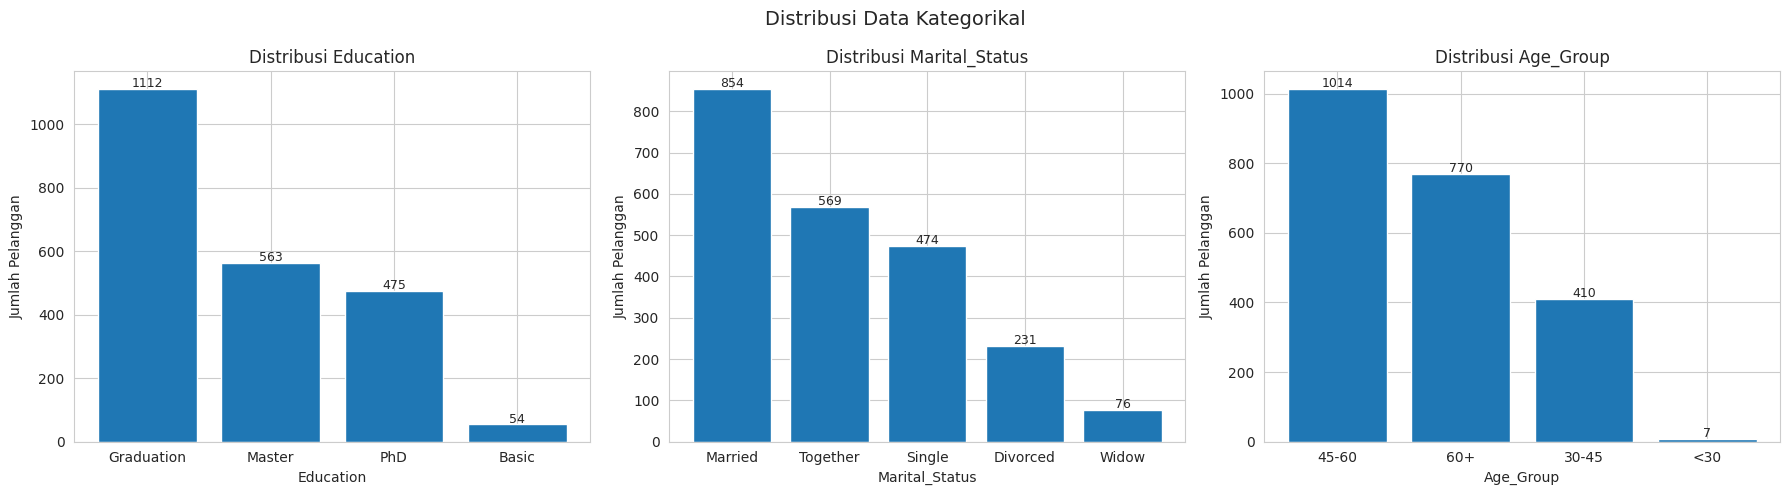

=== Persentase Tiap Kategori ===

--- Education ---
Education
Graduation    50.5
Master        25.5
PhD           21.6
Basic          2.5
Name: count, dtype: float64

--- Marital_Status ---
Marital_Status
Married     38.7
Together    25.8
Single      21.5
Divorced    10.5
Widow        3.4
Name: count, dtype: float64

--- Age_Group ---
Age_Group
45-60    46.0
60+      34.9
30-45    18.6
<30       0.3
Name: count, dtype: float64



In [46]:
# ===========================
# DISTRIBUSI DATA KATEGORIKAL
# ===========================

cat_cols = ['Education', 'Marital_Status', 'Age_Group']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    value_counts = df[col].value_counts()
    axes[i].bar(value_counts.index, value_counts.values)
    axes[i].set_title(f'Distribusi {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah Pelanggan')

    # Tambah angka di atas tiap bar
    for j, v in enumerate(value_counts.values):
        axes[i].text(j, v + 5, str(v),
                     ha='center', fontsize=9)

plt.suptitle('Distribusi Data Kategorikal', fontsize=14)
plt.tight_layout()
plt.show()

# Tampilkan persentase
print("=== Persentase Tiap Kategori ===\n")
for col in cat_cols:
    print(f"--- {col} ---")
    pct = (df[col].value_counts() / len(df) * 100).round(1)
    print(pct)
    print()

**Distribusi Data Kategorikal**

Dari distribusi kolom kategorikal, diperoleh gambaran demografis pelanggan
yang cukup jelas. Dari sisi pendidikan, mayoritas pelanggan merupakan lulusan
Graduation (50.5%), diikuti Master (25.5%) dan PhD (21.6%), sehingga 97.5%
pelanggan berpendidikan tinggi. Hanya 2.5% pelanggan yang memiliki latar
belakang pendidikan Basic.

Dari sisi status pernikahan, sebagian besar pelanggan hidup berpasangan,
baik yang sudah menikah (Married 38.7%) maupun yang tinggal bersama tanpa
ikatan resmi (Together 25.8%), sehingga total 64.5% pelanggan berstatus
berpasangan. Sisanya terbagi antara Single (21.5%), Divorced (10.5%),
dan Widow (3.4%).

Dari sisi kelompok usia, dataset ini didominasi oleh pelanggan berusia
45–60 tahun (46.0%) dan 60 tahun ke atas (34.9%), sehingga lebih dari
80% pelanggan berusia di atas 45 tahun. Kelompok usia 30–45 tahun hanya
18.6%, sementara pelanggan di bawah 30 tahun hampir tidak ada (0.3%,
hanya 7 orang). Ini mengindikasikan bahwa produk perusahaan lebih banyak
diminati oleh kalangan middle-aged hingga senior.

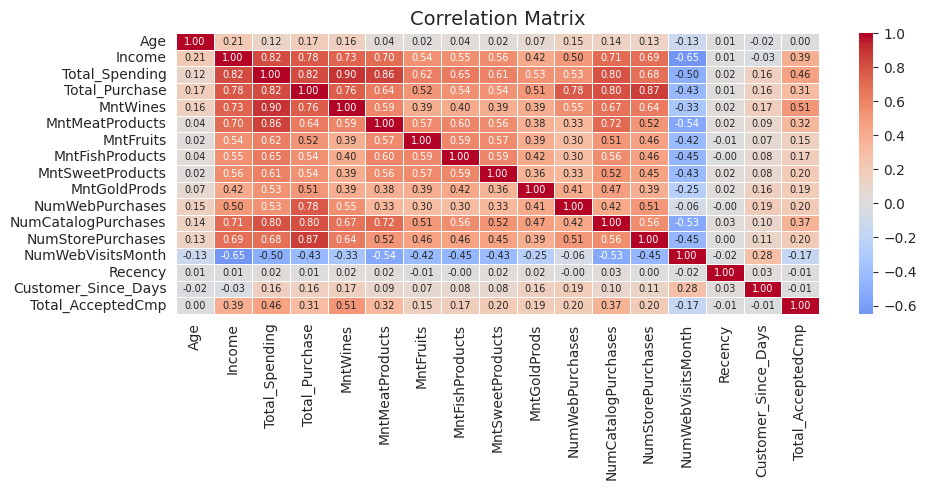

=== Korelasi Kuat (|r| > 0.5) ===

MntWines                  ↔ Total_Spending            : 0.90
Total_Purchase            ↔ NumStorePurchases         : 0.87
MntMeatProducts           ↔ Total_Spending            : 0.86
Income                    ↔ Total_Spending            : 0.82
Total_Spending            ↔ Total_Purchase            : 0.82
Total_Purchase            ↔ NumCatalogPurchases       : 0.80
NumCatalogPurchases       ↔ Total_Spending            : 0.80
Income                    ↔ Total_Purchase            : 0.78
Total_Purchase            ↔ NumWebPurchases           : 0.78
MntWines                  ↔ Total_Purchase            : 0.76
Income                    ↔ MntWines                  : 0.73
MntMeatProducts           ↔ NumCatalogPurchases       : 0.72
NumCatalogPurchases       ↔ Income                    : 0.71
Income                    ↔ MntMeatProducts           : 0.70
NumStorePurchases         ↔ Income                    : 0.69
Total_Spending            ↔ NumStorePurchases     

In [49]:
# ================================
# ANALISIS HUBUNGAN ANTAR VARIABEL
# ================================

# 1. CORRELATION MATRIX
corr_cols = [
    'Age', 'Income', 'Total_Spending', 'Total_Purchase',
    'MntWines', 'MntMeatProducts', 'MntFruits',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth',
    'Recency', 'Customer_Since_Days', 'Total_AcceptedCmp'
]

plt.figure(figsize=(10, 5))
corr_matrix = df[corr_cols].corr()

sns.heatmap(
    corr_matrix,
    annot    = True,
    fmt      = '.2f',
    cmap     = 'coolwarm',
    center   = 0,
    linewidths = 0.5,
    annot_kws = {'size': 7}
)

plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# 2. HIGHLIGHT KORELASI KUAT (> 0.5 atau < -0.5)
print("=== Korelasi Kuat (|r| > 0.5) ===\n")

corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[
    (abs(corr_pairs) > 0.5) &
    (corr_pairs != 1.0)
].sort_values(ascending=False)

# Hapus duplikat
seen = set()
for (col1, col2), val in corr_pairs.items():
    pair = tuple(sorted([col1, col2]))
    if pair not in seen:
        seen.add(pair)
        print(f"{col1:25} ↔ {col2:25} : {val:.2f}")

**Analisis Korelasi Antar Variabel**

Dari correlation matrix, ditemukan beberapa hubungan antar variabel
yang signifikan. Income terbukti menjadi variabel sentral yang berkorelasi
kuat dengan hampir seluruh variabel spending dan purchase, mengonfirmasi
bahwa daya beli pelanggan sangat dipengaruhi oleh tingkat pendapatannya.

MntWines memiliki korelasi tertinggi dengan Total_Spending (r=0.90),
menunjukkan bahwa wine adalah kontributor terbesar pengeluaran pelanggan.
Diikuti MntMeatProducts (r=0.86) sebagai kontributor terbesar kedua.
Dari sisi channel, Total_Purchase berkorelasi paling kuat dengan
NumStorePurchases (r=0.87), yang kembali menegaskan bahwa store adalah
channel transaksi utama pelanggan.

Temuan menarik ditemukan pada korelasi negatif NumWebVisitsMonth.
Variabel ini berkorelasi negatif dengan Income (-0.65), Total_Spending
(-0.50), dan NumCatalogPurchases (-0.53). Artinya, pelanggan yang sering
mengunjungi website justru cenderung berpenghasilan lebih rendah,
berbelanja lebih sedikit, dan jarang menggunakan catalog. Ini mengindikasikan
adanya dua segmen perilaku yang berbeda, pelanggan high-value yang
lebih suka belanja langsung di store atau via catalog, dan pelanggan
low-value yang lebih banyak browsing web namun jarang melakukan pembelian.

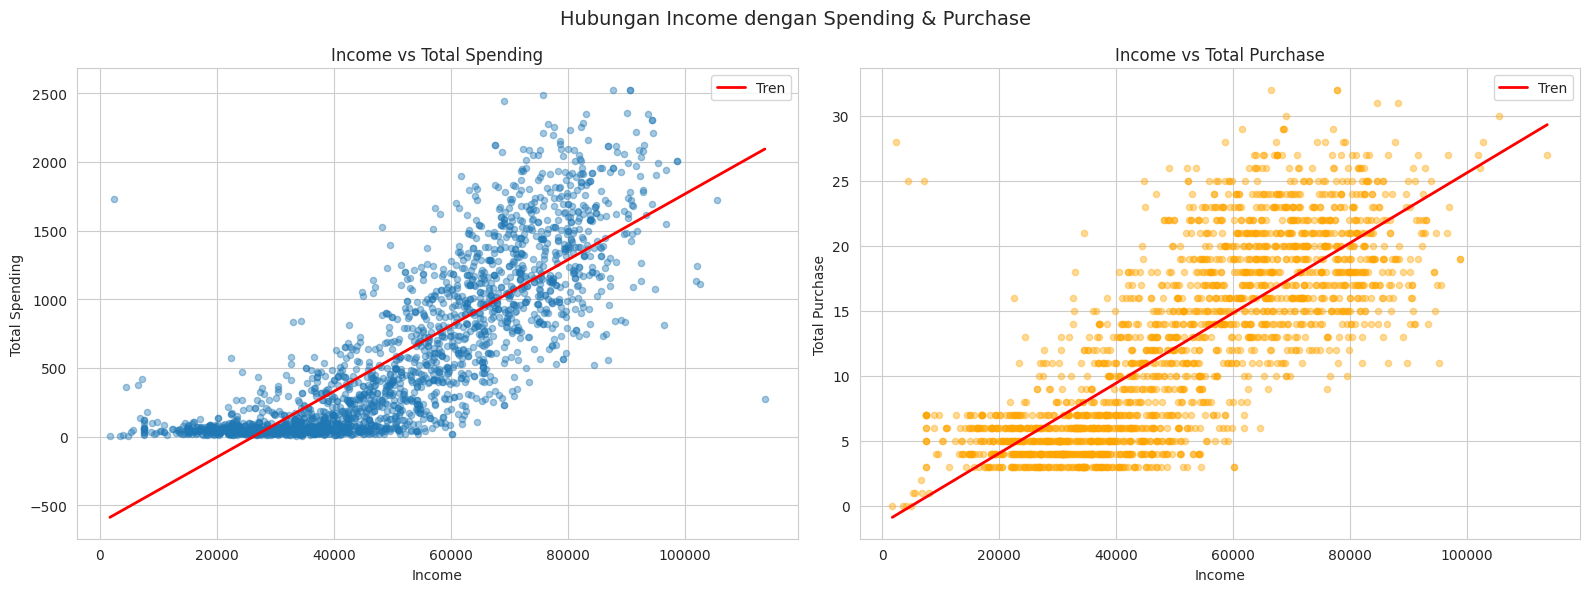

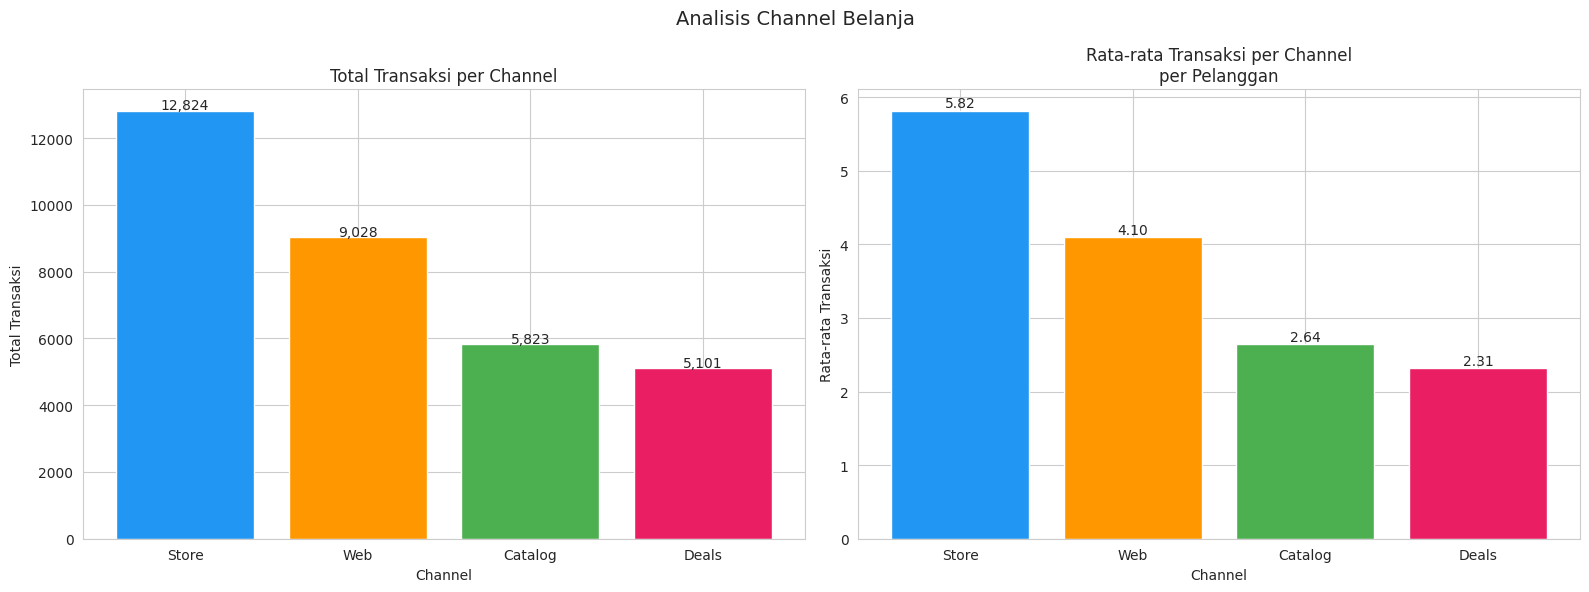

=== Kontribusi Channel (%) ===
Store     : 12,824 (39.1%)
Web       : 9,028 (27.5%)
Catalog   : 5,823 (17.8%)
Deals     : 5,101 (15.6%)


In [50]:
# ==================
# INCOME VS SPENDING
# ==================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter plot Income vs Total_Spending
axes[0].scatter(
    df['Income'], df['Total_Spending'],
    alpha=0.4, s=20
)
# Tambah garis tren
z = np.polyfit(df['Income'], df['Total_Spending'], 1)
p = np.poly1d(z)
axes[0].plot(
    sorted(df['Income']),
    p(sorted(df['Income'])),
    color='red', linewidth=2,
    label='Tren'
)
axes[0].set_title('Income vs Total Spending', fontsize=12)
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Total Spending')
axes[0].legend()

# 2. Scatter plot Income vs Total_Purchase
axes[1].scatter(
    df['Income'], df['Total_Purchase'],
    alpha=0.4, s=20, color='orange'
)
z2 = np.polyfit(df['Income'], df['Total_Purchase'], 1)
p2 = np.poly1d(z2)
axes[1].plot(
    sorted(df['Income']),
    p2(sorted(df['Income'])),
    color='red', linewidth=2,
    label='Tren'
)
axes[1].set_title('Income vs Total Purchase', fontsize=12)
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Total Purchase')
axes[1].legend()

plt.suptitle('Hubungan Income dengan Spending & Purchase', fontsize=14)
plt.tight_layout()
plt.show()


# ===============
# CHANNEL FAVORIT
# ===============

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Total transaksi per channel
channels = {
    'Store'  : df['NumStorePurchases'].sum(),
    'Web'    : df['NumWebPurchases'].sum(),
    'Catalog': df['NumCatalogPurchases'].sum(),
    'Deals'  : df['NumDealsPurchases'].sum()
}
channel_df = pd.DataFrame(
    channels.items(),
    columns=['Channel', 'Total Transaksi']
).sort_values('Total Transaksi', ascending=False)

axes[0].bar(
    channel_df['Channel'],
    channel_df['Total Transaksi'],
    color=['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
)
for i, v in enumerate(channel_df['Total Transaksi']):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)
axes[0].set_title('Total Transaksi per Channel', fontsize=12)
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Total Transaksi')

# 2. Rata-rata transaksi per channel per pelanggan
channels_avg = {
    'Store'  : df['NumStorePurchases'].mean(),
    'Web'    : df['NumWebPurchases'].mean(),
    'Catalog': df['NumCatalogPurchases'].mean(),
    'Deals'  : df['NumDealsPurchases'].mean()
}
channel_avg_df = pd.DataFrame(
    channels_avg.items(),
    columns=['Channel', 'Rata-rata per Pelanggan']
).sort_values('Rata-rata per Pelanggan', ascending=False)

axes[1].bar(
    channel_avg_df['Channel'],
    channel_avg_df['Rata-rata per Pelanggan'],
    color=['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
)
for i, v in enumerate(channel_avg_df['Rata-rata per Pelanggan']):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)
axes[1].set_title('Rata-rata Transaksi per Channel\nper Pelanggan', fontsize=12)
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Rata-rata Transaksi')

plt.suptitle('Analisis Channel Belanja', fontsize=14)
plt.tight_layout()
plt.show()

# Persentase kontribusi tiap channel
print("=== Kontribusi Channel (%) ===")
total = sum(channels.values())
for ch, val in sorted(channels.items(),
                       key=lambda x: x[1], reverse=True):
    print(f"{ch:10}: {val:,} ({val/total*100:.1f}%)")


**Analisis Income vs Spending & Channel Belanja**

Dari scatter plot Income vs Total Spending, terlihat tren positif yang jelas semakin tinggi income pelanggan, semakin besar total pengeluarannya. Namun titik data yang cukup menyebar terutama di rentang income menengah (40.000–70.000) menunjukkan bahwa income bukan satu-satunya faktor penentu spending. Ada pelanggan dengan income serupa namun perilaku belanjanya sangat berbeda, yang mengindikasikan adanya segmen-segmen pelanggan yang perlu diidentifikasi lebih lanjut melalui clustering.

Pola serupa terlihat pada Income vs Total Purchase, hubungan positif ada namun lebih menyebar, konsisten dengan nilai korelasi 0.78. Ini mengonfirmasi bahwa frekuensi pembelian juga dipengaruhi faktor lain di luar income seperti gaya hidup dan preferensi produk.

Dari analisis channel belanja, Store menjadi channel yang paling dominan dengan 12.824 transaksi (39.1%) dan rata-rata 5.82 transaksi per pelanggan. Web berada di posisi kedua dengan 9.028 transaksi (27.5%), diikuti Catalog (17.8%) dan Deals (15.6%). Temuan ini menunjukkan bahwa meskipun era digital terus berkembang, pelanggan dataset ini masih lebih nyaman berbelanja secara langsung di toko dibandingkan channel lainnya.

Berdasarkan hasil dari Exploratory Data Analysis (EDA) diperoleh inisght untuk menjawab tujuan nomor 3, 4, dan 5 sebelumnya

**3. Faktor apa yang memengaruhi pelanggan untuk membeli?**

Berdasarkan analisis korelasi, Income terbukti menjadi faktor yang paling
berpengaruh terhadap total pengeluaran pelanggan dengan nilai korelasi
sebesar 0.82. Artinya, semakin tinggi pendapatan pelanggan, semakin besar
kecenderungan mereka untuk berbelanja. Selain income, jumlah anak kecil di
rumah (Kidhome) memiliki korelasi negatif yang cukup kuat, mengindikasikan
bahwa pelanggan dengan lebih banyak anak kecil cenderung memiliki pengeluaran
belanja yang lebih rendah, kemungkinan karena prioritas pengeluaran rumah
tangga yang lebih terbagi. Faktor usia dan recency terbukti tidak terlalu
berpengaruh karena nilai korelasinya mendekati nol.

**4. Apakah pelanggan dengan pendapatan tinggi selalu lebih sering membeli?**

Dari scatter plot Income vs Total Purchase, terlihat bahwa hubungan positif
memang ada, pelanggan berpenghasilan tinggi cenderung lebih sering membeli.
Namun hubungan ini tidak mutlak, ditunjukkan oleh nilai korelasi 0.78 dan
sebaran titik data yang cukup lebar terutama di rentang income menengah.
Artinya income bukan satu-satunya penentu frekuensi pembelian. Ada pelanggan
berpenghasilan tinggi yang frekuensi belinya tidak terlalu banyak, dan
sebaliknya ada pelanggan dengan income menengah yang cukup aktif berbelanja.
Faktor lain seperti gaya hidup, preferensi produk, dan responsivitas terhadap
promosi juga turut memengaruhi keputusan pembelian.

**5. Pelanggan lebih suka belanja lewat channel apa?**

Dari analisis channel belanja, Store menjadi channel yang paling dominan
dengan total 12.824 transaksi (39.1%) dan rata-rata 5.82 transaksi per
pelanggan. Web berada di posisi kedua dengan 9.028 transaksi (27.5%) dan
rata-rata 4.10 per pelanggan, diikuti Catalog (17.8%) dan Deals (15.6%).
Temuan ini menunjukkan bahwa meskipun era digital terus berkembang,
pelanggan dalam dataset ini masih lebih nyaman berbelanja secara langsung
di toko. Hal ini juga konsisten dengan temuan korelasi sebelumnya bahwa
pelanggan yang sering mengunjungi website justru cenderung memiliki spending
lebih rendah, mereka banyak browsing namun tidak selalu berakhir dengan
pembelian.

# CLUSTERING (K-MEANS)

In [51]:
# ==============================
# K-MEANS CLUSTERING
# ==============================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==============================
# 1. PILIH FITUR CLUSTERING
# ==============================
# Fitur dipilih berdasarkan hasil EDA:
# - Income      : faktor utama yang mempengaruhi spending
# - Total_Spending : representasi nilai belanja pelanggan
# - Recency     : mengukur keaktifan pelanggan
# - Total_Purchase : frekuensi transaksi pelanggan

X = df[['Income', 'Total_Spending', 'Recency', 'Total_Purchase']]

print("=== Fitur yang digunakan ===")
print(X.describe())

=== Fitur yang digunakan ===
              Income  Total_Spending      Recency  Total_Purchase
count    2204.000000     2204.000000  2204.000000     2204.000000
mean    51617.730490      606.510436    49.052178       12.556715
std     20721.492888      602.352523    28.931031        7.184297
min      1730.000000        5.000000     0.000000        0.000000
25%     35191.500000       69.000000    24.000000        6.000000
50%     51301.000000      396.000000    49.000000       12.000000
75%     68289.750000     1045.500000    74.000000       18.000000
max    113734.000000     2525.000000    99.000000       32.000000


In [52]:
# ==============================
# 2. NORMALISASI DATA
# ==============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=== Sebelum Normalisasi ===")
print(pd.DataFrame(X).describe().round(2))

print("\n=== Sesudah Normalisasi ===")
print(pd.DataFrame(
    X_scaled,
    columns=['Income', 'Total_Spending',
             'Recency', 'Total_Purchase']
).describe().round(2))

=== Sebelum Normalisasi ===
          Income  Total_Spending  Recency  Total_Purchase
count    2204.00         2204.00  2204.00         2204.00
mean    51617.73          606.51    49.05           12.56
std     20721.49          602.35    28.93            7.18
min      1730.00            5.00     0.00            0.00
25%     35191.50           69.00    24.00            6.00
50%     51301.00          396.00    49.00           12.00
75%     68289.75         1045.50    74.00           18.00
max    113734.00         2525.00    99.00           32.00

=== Sesudah Normalisasi ===
        Income  Total_Spending  Recency  Total_Purchase
count  2204.00         2204.00  2204.00         2204.00
mean      0.00            0.00     0.00            0.00
std       1.00            1.00     1.00            1.00
min      -2.41           -1.00    -1.70           -1.75
25%      -0.79           -0.89    -0.87           -0.91
50%      -0.02           -0.35    -0.00           -0.08
75%       0.80            0.7

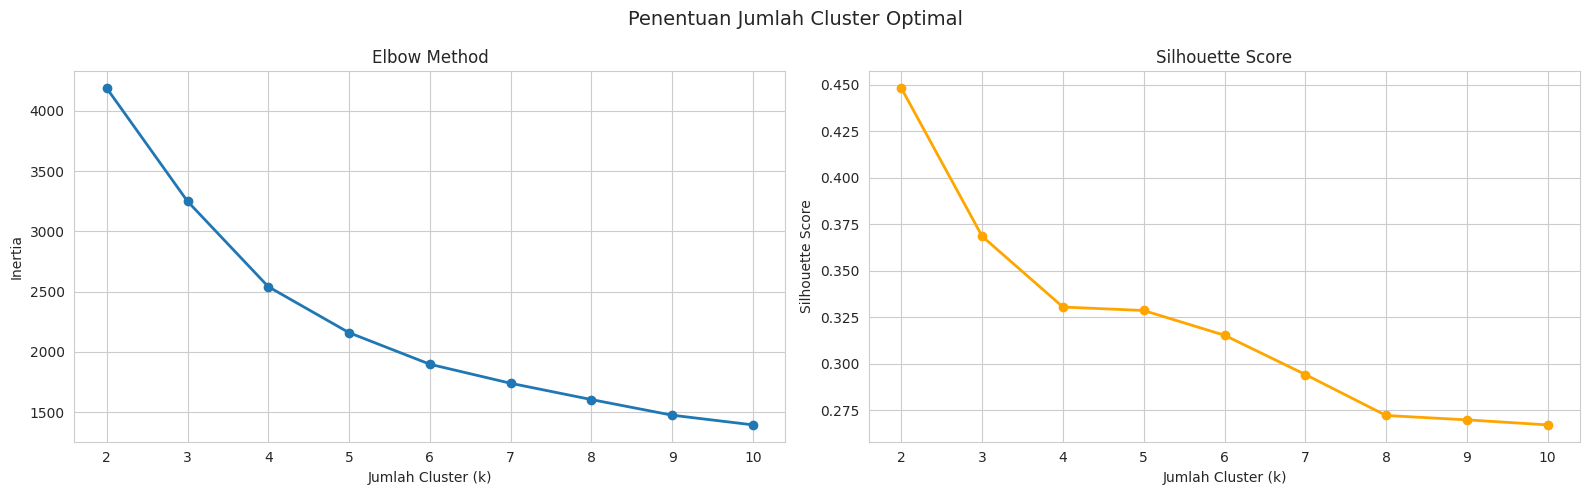

=== Tabel Inertia & Silhouette Score ===

 k  Inertia  Silhouette Score
 2  4188.67             0.448
 3  3249.66             0.368
 4  2540.78             0.330
 5  2158.94             0.329
 6  1897.16             0.315
 7  1739.12             0.294
 8  1603.82             0.272
 9  1474.12             0.270
10  1393.79             0.267


In [53]:
# ==============================
# 3. ELBOW METHOD
# ==============================

inertia      = []
sil_scores   = []
K            = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow & Silhouette Score berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow
axes[0].plot(K, inertia, marker='o', linewidth=2)
axes[0].set_title('Elbow Method', fontsize=12)
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

# Silhouette Score
axes[1].plot(K, sil_scores, marker='o',
             linewidth=2, color='orange')
axes[1].set_title('Silhouette Score', fontsize=12)
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.suptitle('Penentuan Jumlah Cluster Optimal', fontsize=14)
plt.tight_layout()
plt.show()

# Tabel nilai
print("=== Tabel Inertia & Silhouette Score ===\n")
result_df = pd.DataFrame({
    'k'                : list(K),
    'Inertia'          : [round(i, 2) for i in inertia],
    'Silhouette Score' : [round(s, 3) for s in sil_scores]
})
print(result_df.to_string(index=False))

In [54]:
# ==============================
# 4. BUILD MODEL K-MEANS (k=4)
# ==============================

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Tambahkan label cluster ke dataframe
df['Cluster'] = kmeans.labels_

# Evaluasi
sil = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score (k=4) : {sil:.3f}")
print(f"\nJumlah pelanggan tiap cluster:")
print(df['Cluster'].value_counts().sort_index())

Silhouette Score (k=4) : 0.330

Jumlah pelanggan tiap cluster:
Cluster
0    508
1    580
2    617
3    499
Name: count, dtype: int64


In [55]:
# ==============================
# 5. KARAKTERISTIK TIAP CLUSTER
# ==============================

cluster_summary = df.groupby('Cluster').agg(
    Jumlah_Pelanggan  = ('Income', 'count'),
    Avg_Income        = ('Income', 'mean'),
    Avg_Total_Spending= ('Total_Spending', 'mean'),
    Avg_Total_Purchase= ('Total_Purchase', 'mean'),
    Avg_Recency       = ('Recency', 'mean'),
    Avg_Age           = ('Age', 'mean'),
    Avg_AcceptedCmp   = ('Total_AcceptedCmp', 'mean')
).round(1)

print("\n=== Rata-rata Tiap Cluster ===")
print(cluster_summary)


=== Rata-rata Tiap Cluster ===
         Jumlah_Pelanggan  Avg_Income  Avg_Total_Spending  Avg_Total_Purchase  \
Cluster                                                                         
0                     508     70315.7              1198.0                19.3   
1                     580     35347.8               132.7                 6.7   
2                     617     37053.8               148.2                 7.1   
3                     499     69501.4              1121.7                19.2   

         Avg_Recency  Avg_Age  Avg_AcceptedCmp  
Cluster                                         
0               73.5     58.7              0.5  
1               23.1     53.7              0.1  
2               73.5     55.1              0.1  
3               24.1     57.9              0.5  


In [58]:
# =================
# 6.LABELING CLUSTER
# =================
cluster_labels = {
    0: 'Pelanggan Berisiko',
    1: 'Pelanggan Biasa',
    2: 'Pelanggan Tidak Aktif',
    3: 'Pelanggan Setia'
}
df['Cluster_Label'] = df['Cluster'].map(cluster_labels)

# ==============================
# 7. RINGKASAN PROFIL CLUSTER
# ==============================
print("=== Ringkasan Profil Cluster ===\n")
for label in ['Pelanggan Setia', 'Pelanggan Berisiko',
              'Pelanggan Biasa', 'Pelanggan Tidak Aktif']:
    row = df[df['Cluster_Label'] == label]
    print(f"[{label}] — {len(row)} pelanggan")
    print(f"  Avg Income        : {row['Income'].mean():,.0f}")
    print(f"  Avg Total Spending: {row['Total_Spending'].mean():,.0f}")
    print(f"  Avg Total Purchase: {row['Total_Purchase'].mean():.1f}")
    print(f"  Avg Recency       : {row['Recency'].mean():.1f} hari")
    print()

=== Ringkasan Profil Cluster ===

[Pelanggan Setia] — 499 pelanggan
  Avg Income        : 69,501
  Avg Total Spending: 1,122
  Avg Total Purchase: 19.2
  Avg Recency       : 24.1 hari

[Pelanggan Berisiko] — 508 pelanggan
  Avg Income        : 70,316
  Avg Total Spending: 1,198
  Avg Total Purchase: 19.3
  Avg Recency       : 73.5 hari

[Pelanggan Biasa] — 580 pelanggan
  Avg Income        : 35,348
  Avg Total Spending: 133
  Avg Total Purchase: 6.7
  Avg Recency       : 23.1 hari

[Pelanggan Tidak Aktif] — 617 pelanggan
  Avg Income        : 37,054
  Avg Total Spending: 148
  Avg Total Purchase: 7.1
  Avg Recency       : 73.5 hari



In [59]:
# ==============================
# 8. SAVE HASIL CLUSTERING
# ==============================

cols_to_save = [
    'Year_Birth', 'Age', 'Age_Group',
    'Education', 'Marital_Status',
    'Income', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'Total_Spending', 'Total_Purchase', 'Total_AcceptedCmp',
    'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumDealsPurchases',
    'NumWebVisitsMonth', 'Customer_Since_Days',
    'Kidhome', 'Teenhome',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4', 'AcceptedCmp5', 'Response',
    'Cluster', 'Cluster_Label'  # hasil clustering
]

df_final = df[cols_to_save].copy()

df_final.to_csv('customer_segmentation_final.csv', index=True)
print("✅ File berhasil disimpan: customer_segmentation_final.csv")
print(f"Shape: {df_final.shape}")
print(f"\nJumlah pelanggan tiap cluster:")
print(df_final.groupby(['Cluster', 'Cluster_Label'])
      .size().reset_index(name='Jumlah'))

print("\nPreview data:")
df_final.head()

✅ File berhasil disimpan: customer_segmentation_final.csv
Shape: (2204, 32)

Jumlah pelanggan tiap cluster:
   Cluster          Cluster_Label  Jumlah
0        0     Pelanggan Berisiko     508
1        1        Pelanggan Biasa     580
2        2  Pelanggan Tidak Aktif     617
3        3        Pelanggan Setia     499

Preview data:


,Year_Birth,Age,Age_Group,Education,Marital_Status,Income,Recency,MntWines,MntFruits,MntMeatProducts,...,Kidhome,Teenhome,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Cluster,Cluster_Label
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,68,60+,Graduation,Single,58138.0,58,635,88,546,...,0,0,0,0,0,0,0,1,0,Pelanggan Berisiko
2174,1954,71,60+,Graduation,Single,46344.0,38,11,1,6,...,1,1,0,0,0,0,0,0,1,Pelanggan Biasa
4141,1965,60,45-60,Graduation,Together,71613.0,26,426,49,127,...,0,0,0,0,0,0,0,0,3,Pelanggan Setia
6182,1984,41,30-45,Graduation,Together,26646.0,26,11,4,20,...,1,0,0,0,0,0,0,0,1,Pelanggan Biasa
5324,1981,44,30-45,PhD,Married,58293.0,94,173,43,118,...,1,0,0,0,0,0,0,0,2,Pelanggan Tidak Aktif


## Interpretasi & Rekomendasi Strategi per Segmen

### Pelanggan Setia — 499 pelanggan

**Siapa mereka?**
Ini adalah pelanggan terbaik perusahaan. Pendapatan mereka tinggi, pengeluaran
besar, dan masih aktif berbelanja — ditandai dengan Recency rendah (rata-rata
24 hari sejak pembelian terakhir). Singkatnya, mereka sering beli dan selalu
beli dalam jumlah besar.

**Rekomendasi Strategi:**
Jangan sampai mereka pergi. Berikan pengalaman belanja yang eksklusif dan
personal seperti program loyalitas, akses lebih awal ke produk baru, atau
penawaran khusus berdasarkan riwayat belanja mereka. Segmen ini adalah sumber
pendapatan terbesar perusahaan, jadi investasi untuk mempertahankan mereka
sangat worth it.


### Pelanggan Berisiko — 508 pelanggan

**Siapa mereka?**
Dari sisi pendapatan dan total belanja, profil mereka hampir sama dengan
Pelanggan Setia. Tapi ada satu perbedaan besar: mereka sudah lama tidak
berbelanja (rata-rata 73 hari). Artinya, ini adalah pelanggan bernilai tinggi
yang mulai menjauh — dan kalau dibiarkan, mereka bisa benar-benar hilang.

**Rekomendasi Strategi:**
Segmen ini harus jadi prioritas utama tim marketing sekarang juga. Hubungi
mereka secara personal lewat email atau notifikasi dengan penawaran diskon
eksklusif yang terasa dibuat khusus untuk mereka. Ingatkan mereka tentang
produk yang pernah dibeli sebelumnya. Semakin cepat ditindaklanjuti, semakin
besar peluang mereka untuk kembali.


### Pelanggan Biasa — 580 pelanggan

**Siapa mereka?**
Pelanggan di segmen ini masih aktif berbelanja (Recency rendah, rata-rata 23
hari), tapi jumlah yang mereka belanjakan masih kecil. Mereka berbelanja
secukupnya dan kemungkinan besar belum terlalu mengenal produk-produk yang
lebih premium.

**Rekomendasi Strategi:**
Potensi mereka masih bisa digali lebih jauh. Dorong mereka untuk mencoba produk
lain lewat strategi bundling, rekomendasi produk yang relevan, atau penawaran
"coba produk baru dengan harga spesial". Tujuannya adalah meningkatkan nilai
belanja mereka sedikit demi sedikit hingga mereka bisa naik ke segmen yang
lebih tinggi.

### Pelanggan Tidak Aktif — 617 pelanggan

**Siapa mereka?**
Segmen ini adalah yang paling perlu diwaspadai. Pendapatan rendah, belanja
sedikit, jarang transaksi, dan sudah lama tidak berbelanja (rata-rata 73 hari).
Kombinasi ini menunjukkan bahwa mereka sudah hampir tidak terlibat lagi dengan
perusahaan.

**Rekomendasi Strategi:**
Langkah pertama adalah memahami kenapa mereka berhenti — apakah karena harga,
pengalaman belanja yang kurang memuaskan, atau memang sudah tidak butuh
produknya. Kalau masih ingin dipertahankan, coba kampanye reaktivasi dengan
penawaran menarik seperti diskon besar. Tapi kalau biaya untuk menjangkau
mereka lebih besar dari potensi keuntungannya, lebih bijak untuk mengalihkan
fokus anggaran marketing ke segmen lain yang lebih potensial.

Berikut jawaban atas tujuan 1, 2, dan 3 sebelumnya

**1. Siapa pelanggan yang paling menguntungkan?**

Pelanggan Setia adalah kelompok yang paling menguntungkan bagi perusahaan.
Meski jumlahnya hanya 499 orang, paling sedikit dibanding segmen lain,
mereka memiliki pendapatan dan pengeluaran tertinggi sekaligus masih aktif
berbelanja. Artinya, perusahaan perlu memberikan perhatian lebih pada segmen
ini karena mereka adalah kontributor terbesar terhadap pendapatan.

**2. Apakah kampanye pemasaran sudah efektif?**

Belum sepenuhnya. Tingkat penerimaan kampanye secara keseluruhan masih rendah
di semua segmen. Kampanye hanya terlihat sedikit lebih efektif pada Pelanggan
Setia dan Pelanggan Berisiko dibanding dua segmen lainnya. Ini menunjukkan
bahwa kampanye yang ada belum cukup tepat sasaran, perusahaan perlu beralih
dari pendekatan kampanye massal ke pendekatan yang lebih personal dan
disesuaikan dengan karakteristik tiap segmen.

**3. Faktor apa yang paling memengaruhi pelanggan untuk membeli?**

Berdasarkan analisis korelasi, pendapatan (Income) adalah faktor paling
dominan dengan korelasi 0.82 terhadap total pengeluaran. Namun hasil
clustering membuktikan bahwa pendapatan tinggi saja tidak cukup, Pelanggan
Berisiko memiliki pendapatan tinggi tapi sudah tidak aktif berbelanja.
Artinya, faktor seperti relevansi produk, pengalaman belanja, dan ketepatan
kampanye juga memegang peran penting dalam mendorong pelanggan untuk membeli.

# Kesimpulan

**1. Siapa pelanggan yang paling menguntungkan?**
Pelanggan Setia (499 orang) adalah yang paling menguntungkan, pendapatan tertinggi, belanja terbesar, dan masih aktif. Jumlahnya paling sedikit, tapi kontribusinya paling besar.

**2. Apakah kampanye pemasaran sudah efektif?**
Belum. Tingkat penerimaan kampanye masih rendah di semua segmen. Kampanye perlu beralih dari pendekatan massal ke pendekatan yang lebih personal dan ditargetkan per segmen.

**3. Faktor apa yang paling memengaruhi pelanggan untuk membeli?**
Pendapatan adalah faktor terkuat (korelasi 0.82), tapi bukan satu-satunya Pelanggan Berisiko punya pendapatan tinggi namun sudah tidak aktif, artinya relevansi produk dan pengalaman belanja juga turut menentukan.

**4. Apakah pelanggan berpendapatan tinggi selalu lebih sering membeli?**
Tidak selalu. Ada 508 pelanggan berpendapatan tinggi yang sudah lama tidak berbelanja. Pendapatan tinggi tidak otomatis menjamin keaktifan pembelian.

**5. Pelanggan lebih suka belanja lewat channel apa?**
Store (toko fisik) paling dominan dengan 39.1% transaksi. Menariknya, pelanggan yang sering mengunjungi website justru cenderung berbelanja lebih sedikit, banyak browsing tapi jarang berakhir dengan pembelian.

**6. Pelanggan mana yang mulai tidak aktif?**
Pelanggan Berisiko (508 orang) dan Pelanggan Tidak Aktif (617 orang) keduanya sudah lama tidak berbelanja. Pelanggan Berisiko lebih prioritas karena nilai belanja mereka tinggi dan masih berpotensi untuk kembali.